# IPCA – Entendendo, Coletando e Analisando a Inflação Oficial do Brasil

Este notebook apresenta:

**1. O que é o IPCA**  
**2. Como o índice é calculado**  
**3. Diferença entre IPCA mensal e IPCA acumulado**  
**4. Como interpretar a inflação**  
**5. Como coletar a série do Banco Central**  
**6. Como armazenar no PostgreSQL**  
**7. Como consultar e analisar**  


Vamos começar entendendo o conceito.

# 1. O que é o IPCA?

O IPCA (Índice de Preços ao Consumidor Amplo) é o **índice oficial de inflação do Brasil**, calculado pelo IBGE.

Ele mede a variação de preços de uma cesta de bens e serviços consumidos por famílias com renda entre **1 e 40 salários mínimos**.

O IPCA é usado para:
- metas de inflação do Banco Central
- reajuste de contratos
- política monetária
- análise macroeconômica

O Banco Central replica a série do IBGE no SGS (código **433**), que é a série que vamos usar.

# 2. Como o IPCA é calculado?

O IBGE coleta mensalmente preços de:
- alimentação
- habitação
- transportes
- saúde
- educação
- comunicação
- vestuário
- despesas pessoais

Cada item tem um **peso** na cesta.

O índice mensal representa:

> **A variação percentual média dos preços da cesta no mês.**

Exemplo:
- IPCA de 0,50% → preços subiram 0,50% no mês
- IPCA de -0,10% → deflação

# 3. IPCA mensal vs IPCA acumulado

Existem duas formas comuns de analisar o IPCA:

## ✔ IPCA mensal
- variação do mês
- série SGS 433

## ✔ IPCA acumulado em 12 meses
- soma das variações dos últimos 12 meses
- usado para metas de inflação

Exemplo:
- IPCA mensal = 0,40%
- IPCA 12 meses = 4,20%

# 4. Ajustar o PYTHONPATH para importar `src/`

In [10]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 5. Importações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pipelines.ipca import run_ipca
from src.database.connection import engine

# 6. Executar pipeline IPCA

Isso irá:
- baixar a série SGS 433
- criar automaticamente a tabela `bcb.ipca`
- inserir todos os dados

In [ ]:
run_ipca()

# 7. Verificar tabelas existentes

In [11]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,selic_meta
2,selic_over


# 8. Carregar dados do IPCA

In [12]:
ipca = pd.read_sql("SELECT * FROM bcb.ipca ORDER BY date;", engine)
ipca.head()

,date,value,series_id
0,1980-01-01,6.62,433
1,1980-02-01,4.62,433
2,1980-03-01,6.04,433
3,1980-04-01,5.29,433
4,1980-05-01,5.70,433


# 9. Últimos valores do IPCA

In [13]:
pd.read_sql("""
SELECT *
FROM bcb.ipca
ORDER BY date DESC
LIMIT 12;
""", engine)

,date,value,series_id
0,2026-03-01,0.88,433
1,2026-02-01,0.70,433
2,2026-01-01,0.33,433
3,2025-12-01,0.33,433
4,2025-11-01,0.18,433
5,2025-10-01,0.09,433
6,2025-09-01,0.48,433
7,2025-08-01,-0.11,433
8,2025-07-01,0.26,433
9,2025-06-01,0.24,433


# 10. Estatísticas básicas

In [14]:
ipca.describe()

,date,value,series_id
count,555,555.000000,555.0
mean,2003-01-30 21:00:58.378378,5.548306,433.0
min,1980-01-01 00:00:00,-0.680000,433.0
25%,1991-07-16 12:00:00,0.360000,433.0
50%,2003-02-01 00:00:00,0.710000,433.0
75%,2014-08-16 12:00:00,6.430000,433.0
max,2026-03-01 00:00:00,82.390000,433.0
std,NaN,10.561022,0.0


In [21]:
query_ipca = """
SELECT *
FROM bcb.ipca
WHERE date >= '1996-01-01'
ORDER BY date desc;
"""

ipca_maior96 = pd.read_sql(query_ipca, engine)
ipca_maior96.head(10)


,date,value,series_id
0,2026-03-01,0.88,433
1,2026-02-01,0.70,433
2,2026-01-01,0.33,433
3,2025-12-01,0.33,433
4,2025-11-01,0.18,433
5,2025-10-01,0.09,433
6,2025-09-01,0.48,433
7,2025-08-01,-0.11,433
8,2025-07-01,0.26,433
9,2025-06-01,0.24,433


# 11. Gráfico do IPCA mensal

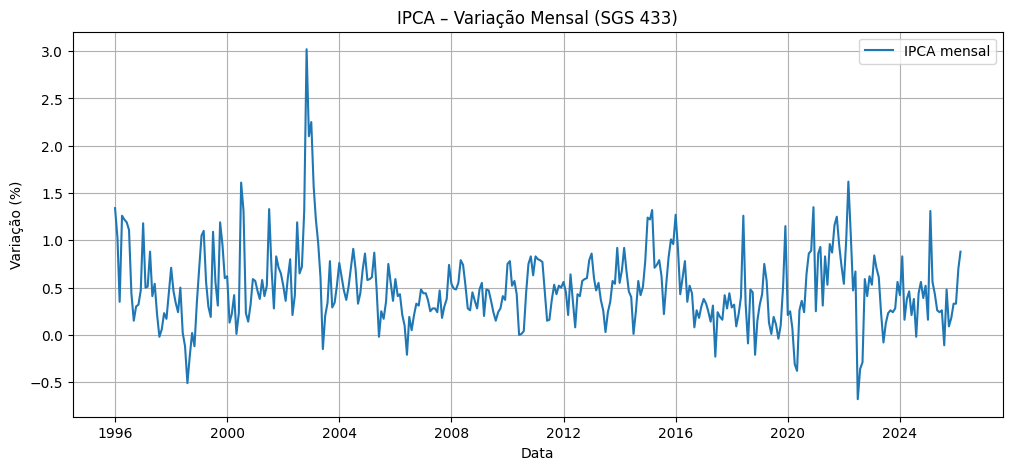

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(ipca_maior96["date"], ipca_maior96["value"], label="IPCA mensal")
plt.title("IPCA – Variação Mensal (SGS 433)")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. IPCA acumulado em 12 meses

O acumulado é a soma das variações dos últimos 12 meses.

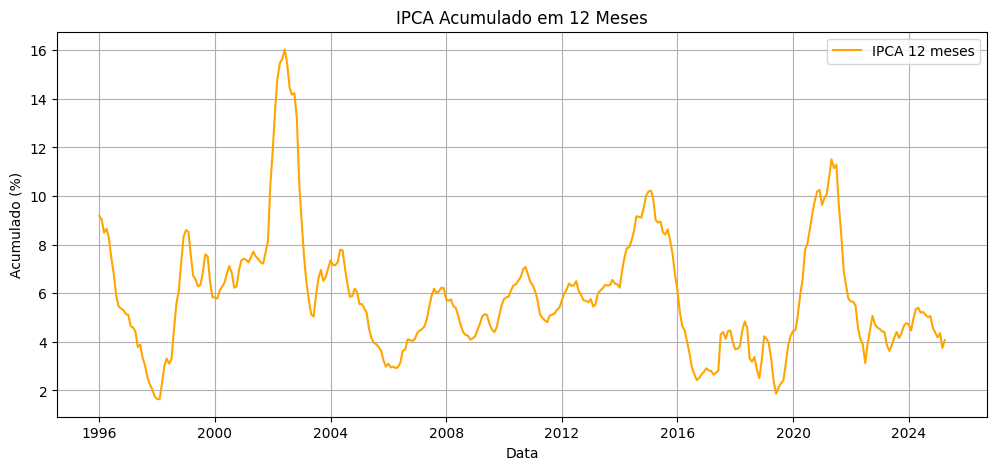

In [25]:
ipca_maior96["ipca_12m"] = ipca_maior96["value"].rolling(12).sum()

plt.figure(figsize=(12, 5))
plt.plot(ipca_maior96["date"], ipca_maior96["ipca_12m"], color="orange", label="IPCA 12 meses")
plt.title("IPCA Acumulado em 12 Meses")
plt.xlabel("Data")
plt.ylabel("Acumulado (%)")
plt.grid(True)
plt.legend()
plt.show()

# 13. Últimos 12 meses do IPCA acumulado

In [26]:
ipca_maior96.tail(12)[["date", "ipca_12m"]]

,date,ipca_12m
351,1996-12-01,5.15
352,1996-11-01,5.30
353,1996-10-01,5.37
354,1996-09-01,5.46
355,1996-08-01,5.92
356,1996-07-01,6.81
357,1996-06-01,7.46
358,1996-05-01,8.27
359,1996-04-01,8.65
360,1996-03-01,8.49


# 14. Comparação: IPCA mensal vs acumulado

Útil para entender:
- tendência de curto prazo (mensal)
- tendência de longo prazo (12 meses)

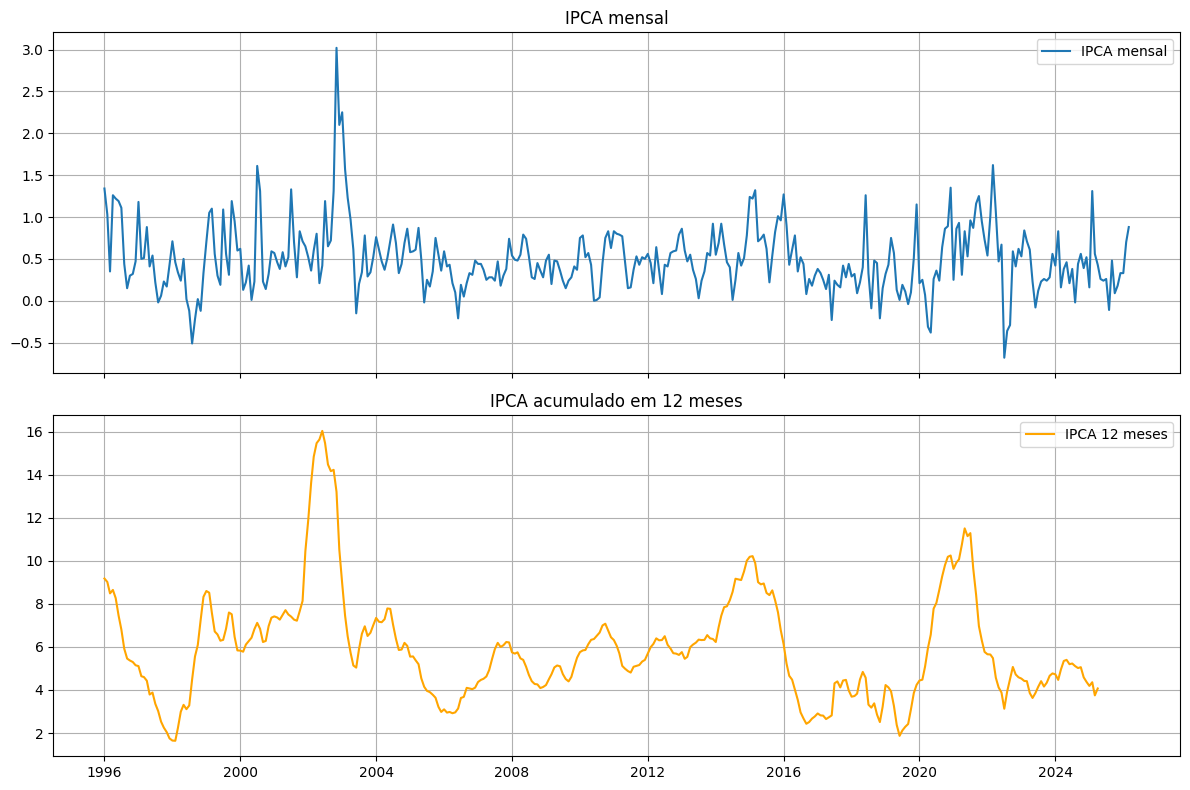

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(ipca_maior96["date"], ipca_maior96["value"], label="IPCA mensal")
ax[0].set_title("IPCA mensal")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(ipca_maior96["date"], ipca_maior96["ipca_12m"], color="orange", label="IPCA 12 meses")
ax[1].set_title("IPCA acumulado em 12 meses")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

# 15. Conclusões

- O IPCA mensal mostra a inflação do mês.
- O IPCA 12 meses mostra a tendência geral.
- O pipeline automatiza a coleta e armazenamento.
- A tabela `bcb.ipca` agora está sempre atualizada.

Este notebook pode ser expandido para:
- IPCA-15
- IPCA por grupos
- IPCA por itens
- decomposição da inflação
- análise sazonal